In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from tensorflow import keras

In [39]:
# carga de los datos para entrenamiento y test.
import os 
print(os.getcwd())
datos_entrenamiento = pd.read_csv('../data/sign_mnist_train/sign_mnist_train.csv')
print(os.path.exists('../data/sign_mnist_train/sign_mnist_train.csv'))
datos_prueba = pd.read_csv('../data/sign_mnist_test/sign_mnist_test.csv')
print(os.path.exists('../data/sign_mnist_test/sign_mnist_test.csv'))

/home/rodricac/Documents/Duouc26_semes2/Tecnicas avanzadas MachineLearning/MLAIimages/proyectAI/notebooks
True
True


In [40]:
# dimension de datos en entrenamiento 
print(f'''
Datos entrenamiento
dimension: {datos_entrenamiento.shape}
cantidad de datos : {datos_entrenamiento.shape[0]} imagenes
dimension de cada imagen: {datos_entrenamiento.shape[1]} pixeles por imagen''')


Datos entrenamiento
dimension: (27455, 785)
cantidad de datos : 27455 imagenes
dimension de cada imagen: 785 pixeles por imagen


In [41]:
# dimension de datos en prueba
print(f'''
Datos Prueba
dimension: {datos_prueba.shape}
cantidad de datos : {datos_prueba.shape[0]} imagenes
dimension de cada imagen: {datos_prueba.shape[1]} pixeles por imagen''')


Datos Prueba
dimension: (7172, 785)
cantidad de datos : 7172 imagenes
dimension de cada imagen: 785 pixeles por imagen


In [42]:
# Informacion detallada en datos de entrenamiento.
print(f'''datos entrenamiento:{datos_entrenamiento.info()}''')

<class 'pandas.DataFrame'>
RangeIndex: 27455 entries, 0 to 27454
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 164.4 MB
datos entrenamiento:None


In [43]:
# informacion detallada en dato de prueba.
print(f'''Datos de prueba: {datos_prueba.info()}''')

<class 'pandas.DataFrame'>
RangeIndex: 7172 entries, 0 to 7171
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 43.0 MB
Datos de prueba: None


In [44]:
# Cantidad de pixeles de la imagen y su dimension
print(f'''Cantidad de pixeles de la imagen: {datos_entrenamiento.shape[1]-1}
dimension: {np.sqrt(datos_entrenamiento.shape[1]-1)}
dimension imagen: {int(np.sqrt(datos_entrenamiento.shape[1]-1))} X {int(np.sqrt(datos_entrenamiento.shape[1]-1))}''')

Cantidad de pixeles de la imagen: 784
dimension: 28.0
dimension imagen: 28 X 28


In [45]:
# label, variable objetivo , verificamos los valores unicos para encontrar la cantidad de clases
clases = datos_entrenamiento['label'].unique()
clases

array([ 3,  6,  2, 13, 16,  8, 22, 18, 10, 20, 17, 19, 21, 23, 24,  1, 12,
       11, 15,  4,  0,  5,  7, 14])

In [46]:
# Separacion de datos para entramiento.
features_train = datos_entrenamiento.drop(columns='label')
label_train = datos_entrenamiento['label']

print(f'''Chequeo de dimensiones entrenamiento, features and label
features : {features_train.shape}
label : {label_train.shape}''')

Chequeo de dimensiones entrenamiento, features and label
features : (27455, 784)
label : (27455,)


In [47]:
# Separacion de datos para test
features_test = datos_prueba.drop(columns='label')
label_test= datos_prueba['label']
print(f'''
Chequeo de dimension para test. fetures_tes and label_test
features_test : {features_test.shape}
label_test: {label_test.shape}''')


Chequeo de dimension para test. fetures_tes and label_test
features_test : (7172, 784)
label_test: (7172,)


In [48]:
# El describe nos proporciona un resumen estadisticos de las variables numericas.
# incluyendo las medidas de media central.
# dispersion y posicion.
features_train.describe()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,...,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000
mean,145.419377,148.500273,151.247714,153.546531,156.210891,158.411255,160.472154,162.339683,163.954799,165.533673,...,141.104863,147.495611,153.325806,159.125332,161.969259,162.736696,162.906137,161.966454,161.137898,159.824731
std,41.358555,39.942152,39.056286,38.595247,37.111165,36.125579,35.016392,33.661998,32.651607,31.279244,...,63.751194,65.512894,64.427412,63.708507,63.738316,63.444008,63.509210,63.298721,63.610415,64.396846
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,121.000000,126.000000,130.000000,133.000000,137.000000,140.000000,142.000000,144.000000,146.000000,148.000000,...,92.000000,96.000000,103.000000,112.000000,120.000000,125.000000,128.000000,128.000000,128.000000,125.500000
50%,150.000000,153.000000,156.000000,158.000000,160.000000,162.000000,164.000000,165.000000,166.000000,167.000000,...,144.000000,162.000000,172.000000,180.000000,183.000000,184.000000,184.000000,182.000000,182.000000,182.000000
75%,174.000000,176.000000,178.000000,179.000000,181.000000,182.000000,183.000000,184.000000,185.000000,186.000000,...,196.000000,202.000000,205.000000,207.000000,208.000000,207.000000,207.000000,206.000000,204.000000,204.000000
max,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000


In [49]:
# funcion normalizar
def normalizar(imagenes, etiquetas):
    """toma las imagenes como caracteristicas y 
    sus etiquetas correspondientes a la clase de cada imagen.
    las imagenes se convierten a un tipo de datos flotante y sus valores de intensidad
    originalmente va desde 0 a 255 valores de intensidad y se normalizan a un rango de 0 a 1.
    Args:
        imagenes (float64): caracteristica de cada imagen representadas
        mediante sus valores de pixeles.
        etiquetas (float64): clase correspondiente a cada imagen.

    Returns:
        float64: retorna un tupla que contiene los valores de intensidad normalizados
        en un rango de 0 a 1 y las etiquetas quedan sin modificar.
    """    
    imagenes = tf.cast(imagenes,tf.float32)
    imagenes/=255
    return imagenes,etiquetas

- El siguiente tratamiento realizara una normalizacion para los valores de los pixeles en cada imagen.
Donde cada imagen esta compuesta por una dimension 784 pixeles, correspondiente a una dimension de 28x28, la intensidad de los valores de los pixeles se encuentran en un rango de 0-255, por lo que seran normalizados en un rango de 0 a 1.

In [50]:
# Normalizacion de los datos para entrenamiento y test
#train
normalized_train, label_train = normalizar(features_train,label_train)
#test
normalized_test , label_test = normalizar(features_test,label_test)

### Distribución de Clases

In [51]:
class_distribution = label_train.value_counts(ascending=False)
difference = class_distribution.max() - class_distribution.min()
print(f'''
distribucion de clases : {class_distribution}
diferencia de clases con mayor imagen y menor imagen
{difference}''')



distribucion de clases : label
17    1294
16    1279
11    1241
22    1225
5     1204
18    1199
3     1196
14    1196
19    1186
23    1164
8     1162
20    1161
13    1151
2     1144
0     1126
24    1118
10    1114
6     1090
15    1088
21    1082
12    1055
7     1013
1     1010
4      957
Name: count, dtype: int64
diferencia de clases con mayor imagen y menor imagen
337


In [52]:
train_counts = {}
for class_number in clases:
    train_counts[class_number] = label_train.value_counts()[class_number]

train_counts


{np.int64(3): np.int64(1196),
 np.int64(6): np.int64(1090),
 np.int64(2): np.int64(1144),
 np.int64(13): np.int64(1151),
 np.int64(16): np.int64(1279),
 np.int64(8): np.int64(1162),
 np.int64(22): np.int64(1225),
 np.int64(18): np.int64(1199),
 np.int64(10): np.int64(1114),
 np.int64(20): np.int64(1161),
 np.int64(17): np.int64(1294),
 np.int64(19): np.int64(1186),
 np.int64(21): np.int64(1082),
 np.int64(23): np.int64(1164),
 np.int64(24): np.int64(1118),
 np.int64(1): np.int64(1010),
 np.int64(12): np.int64(1055),
 np.int64(11): np.int64(1241),
 np.int64(15): np.int64(1088),
 np.int64(4): np.int64(957),
 np.int64(0): np.int64(1126),
 np.int64(5): np.int64(1204),
 np.int64(7): np.int64(1013),
 np.int64(14): np.int64(1196)}

In [53]:
print(len(label_train))
print(len(label_test))

27455
7172


In [54]:
test_counts={}
for test_number in clases:
    test_counts[test_number] = label_test.value_counts()[test_number]
test_counts


{np.int64(3): np.int64(245),
 np.int64(6): np.int64(348),
 np.int64(2): np.int64(310),
 np.int64(13): np.int64(291),
 np.int64(16): np.int64(164),
 np.int64(8): np.int64(288),
 np.int64(22): np.int64(206),
 np.int64(18): np.int64(246),
 np.int64(10): np.int64(331),
 np.int64(20): np.int64(266),
 np.int64(17): np.int64(144),
 np.int64(19): np.int64(248),
 np.int64(21): np.int64(346),
 np.int64(23): np.int64(267),
 np.int64(24): np.int64(332),
 np.int64(1): np.int64(432),
 np.int64(12): np.int64(394),
 np.int64(11): np.int64(209),
 np.int64(15): np.int64(347),
 np.int64(4): np.int64(498),
 np.int64(0): np.int64(331),
 np.int64(5): np.int64(247),
 np.int64(7): np.int64(436),
 np.int64(14): np.int64(246)}

In [55]:
pd.set_option('display.max_rows',None)
difference_class = pd.DataFrame(
    {
        "class":clases,
        "train_counts" : [train_counts[c] for c in clases],
        "test_counts" : [test_counts[c] for c in clases]
    }
)
difference_class

,class,train_counts,test_counts
0,3,1196,245
1,6,1090,348
2,2,1144,310
3,13,1151,291
4,16,1279,164
5,8,1162,288
6,22,1225,206
7,18,1199,246
8,10,1114,331
9,20,1161,266


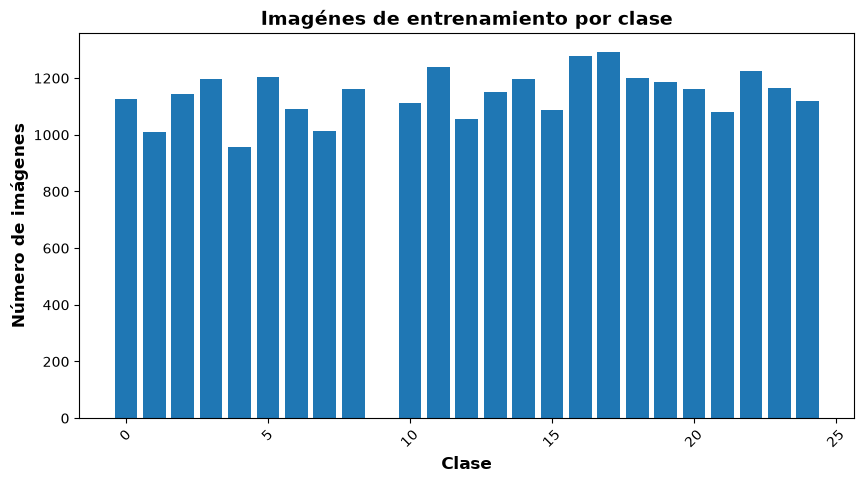

In [56]:
plt.figure(figsize=(10,5))
plt.bar(
    difference_class['class'],
    difference_class['train_counts']
)
plt.title("Imagénes de entrenamiento por clase", fontsize=14, fontweight="bold")
plt.xlabel("Clase", fontsize=12, fontweight="bold")
plt.ylabel("Número de imágenes", fontsize=12, fontweight="bold")
plt.xticks(rotation=45)
plt.show()

In [57]:
difference_class_long = difference_class.melt(
    id_vars="class",
    value_vars=['train_counts','test_counts']
)
difference_class_long.head()

,class,variable,value
0,3,train_counts,1196
1,6,train_counts,1090
2,2,train_counts,1144
3,13,train_counts,1151
4,16,train_counts,1279


In [58]:
difference_class_long['dataset'] = difference_class_long['variable'].map({
    'train_counts': 'Entrenamiento',
    'test_counts': 'Prueba'
})

Text(0.5, 1.0, 'Distribución de clases: entrenamiento vs prueba')

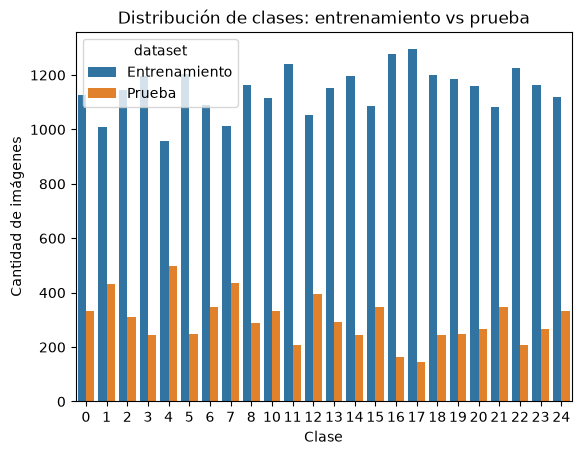

In [59]:
sns.barplot(data=difference_class_long,x='class',y='value',hue='dataset')
plt.ylabel('Cantidad de imágenes')
plt.xlabel('Clase')
plt.title('Distribución de clases: entrenamiento vs prueba')

In [60]:
# al normalizar los datos originales, las caracteristicas se convierten en tensores,por lo tanto se procede a construir un dataset.
# para organizar las caracteristicas y etiquetas.
# dataset train
dataset_train = tf.data.Dataset.from_tensor_slices((normalized_train,label_train))
# dataset test
dataset_test = tf.data.Dataset.from_tensor_slices((normalized_test,label_test))

In [61]:
# Aquí usamos el reshape para darle a TensorFlow la estructura de las imágenes.
# Esto se realiza porque inicialmente cada imagen está representada como
# un vector de 784 píxeles. Como sabemos que 784 = 28 x 28, reorganizamos
# esos valores para que TensorFlow interprete cada imagen como una matriz
# de 28 x 28 píxeles.
x_train  = tf.reshape(normalized_train,(-1,28,28,1))
x_test = tf.reshape(normalized_test,(-1,28,28,1))
print(f'''Tensores de 4 dimensiones:
Tensor train : {x_train.shape}
Tensor test : {x_test.shape}''')

Tensores de 4 dimensiones:
Tensor train : (27455, 28, 28, 1)
Tensor test : (7172, 28, 28, 1)


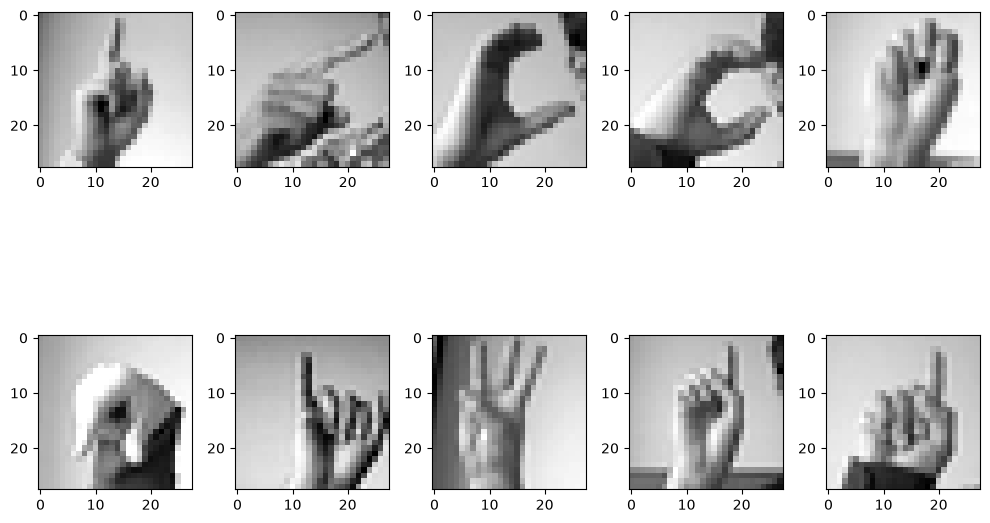

In [62]:
f, ax = plt.subplots(2,5) # mostramos 10 imagenes su dimension es de 2x5, es decir 2 filas x 5 columnas.
f.set_size_inches(10,10) # modificar tamano a pulgadas.
k = 0 # k es nuestro indice para decir que imagen debe mostrar de x_train.
for i in range(2):
    for j in range(5):
# como x_train[k] pide una imagen y nuestra estructura es de 4d, aqui reshape dice que solo quiere la dimension de la imagen que es de 28x28.
# y temporalmente se quita el canal 1.
        ax[i,j].imshow(tf.reshape(x_train[k],(28,28)), cmap='gray')
        k+=1 # aumentamos en indice de k en 1 hasta llegar a 10 que es el total de imagenes que queremos.
    plt.tight_layout()

## Modelo

In [87]:
# NUM_CLASSES = label_train.max()+1
red = keras.Sequential(name="Neuronal_Network_1")
red.add(keras.Input(shape=(28, 28, 1)))
red.add(keras.layers.Flatten())
red.add(keras.layers.Dense(128, activation='relu', name='hidden_layers_1'))
red.add(keras.layers.Dense(64, activation='relu', name='hidden_layers_2'))
red.add(keras.layers.Dense(units=25, activation='softmax', name='layers_output'))

### Se debe respaldar la clase 9 como faltante ya que en la ultima capa de salida contiene 25 neuronas de salida y lo que hace la **activacion de softmax** reproduce inicialmente estos 25 valores por lo que debe existir correspondenia de 25 neuronas y 25 categorias(clases). y nuestro dataset solo contiene 24 clases que verifica en el siguiente codigo.

In [80]:
print(sorted(label_train.unique()))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


# COMPILE

In [88]:
red.compile(
    # utilizamos adam para que se encargue de ajustar los pesos para reducir el error.
    # el optimizar nos indica como se van actualizar los pesos mediante la red de entrenamiento, utilizando Adam.
    optimizer = tf.keras.optimizers.Adam(0.1), 
    # determina que tan buena o mala fue la prediccion, compara la clase real con las probabilidades que produjo softmax.
    loss = 'sparse_categorical_crossentropy', 
    metrics = ['accuracy'] # observacion durante el etrenamiento
)

## FIT

In [89]:
print(f'inicio de entramiento...')
# generamos el entrenamiento donde entregamos por parametros las variables de (x)(caracteristicas,imagenes) y nuestro (y)(etiquetas, label, numero de clases 25).
# el tamano de grupo seran de 32 y nos indica cuantas imagenes procesa antes de actualizar los pesos.
# por ejemplo si nuestro datos son 27455 y que corresponde a la cantidad de imagenes, luego procesa 32 imagenes por grupo 
# calcula la perdida y luego actualiza los pesos.
# hasta completar las epocas.
historial  = red.fit(x_train,label_train,epochs=5,batch_size=32)
print(f'fin de entrenamiento')

inicio de entramiento...
Epoch 1/5


858/858 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.0435 - loss: 3.7261
Epoch 2/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.0424 - loss: 3.1964
Epoch 3/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.0410 - loss: 3.1963
Epoch 4/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0420 - loss: 3.1975
Epoch 5/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.0431 - loss: 3.1970
fin de entrenamiento


In [92]:
print("La precision del modelo es - " , red.evaluate(x_train,label_train)[1]*100 , "%")


858/858 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0452 - loss: 3.1977
La precision del modelo es -  4.520123824477196 %


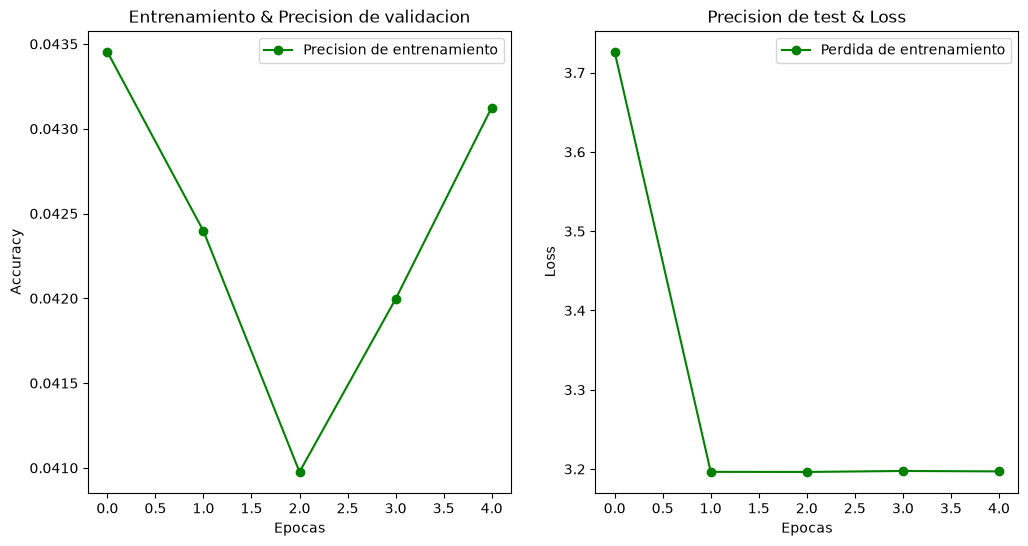

In [ ]:
epochs = [i for i in range(5)] # aqui iteramos en base a las epocas de entrenamiento declaradas en la variable historial.
fig , ax = plt.subplots(1,2)
train_acc = historial.history['accuracy']
train_loss = historial.history['loss']
fig.set_size_inches(12,6)

ax[0].plot(epochs , train_acc , 'go-' , label = 'Precision de entrenamiento')
ax[0].set_title('Entrenamiento & Precision de validacion')
ax[0].legend()
ax[0].set_xlabel("Epocas")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs , train_loss , 'g-o' , label = 'Perdida de entrenamiento')
ax[1].set_title('Precision de test & Loss')
ax[1].legend()
ax[1].set_xlabel("Epocas")
ax[1].set_ylabel("Loss")
plt.show()

# LOSS

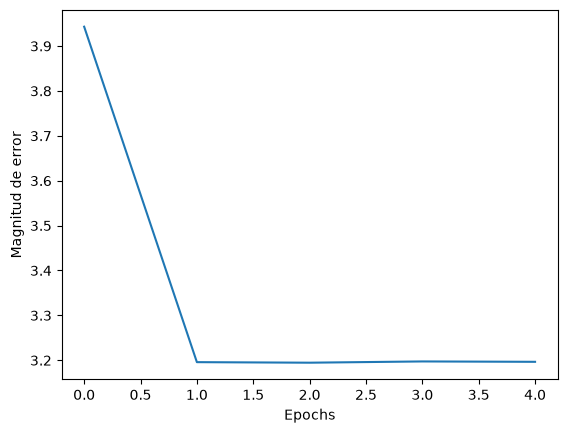

In [83]:
%matplotlib inline
plt.ylabel('Magnitud de error')
plt.xlabel('Epochs')
plt.plot(historial.history['loss'])
plt.grid(False)